# Modelica basics  -  M1 of the system-modelling stream

Separate from the Kaggle engineering notebook. This one is about learning
**acausal, equation-based system modelling** with OpenModelica, starting from
the three canonical first / second-order systems every plant model is built from:

1. mechanical  -  mass-spring-damper
2. electrical  -  RC network
3. thermal  -  a lumped body with conduction to ambient

For each: write the Modelica, simulate it with `omc` (the compiler  -  no GUI),
and check the result against the closed-form solution. Same discipline as the
CFD/heat-transfer work: a model earns trust by reproducing a case with a known
answer before it is used for anything new.

**Why Modelica and not just an ODE solver:** the components connect acausally
(through/across variables, like a circuit), so a pack model is assembled by
wiring parts, not by hand-deriving the system ODE. That is the skill that
transfers to Amesim / GT-SUITE / Simscape.

In [1]:
import os
import shutil
import subprocess
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

OMC = next((p for p in [
    r"D:\OpenModelica\bin\omc.exe",
    r"C:\OpenModelica\bin\omc.exe",
    shutil.which("omc") or "",
] if p and os.path.exists(p)), None)
print("omc:", OMC)

WORK = os.path.abspath("mo_work")
os.makedirs(WORK, exist_ok=True)


def run_modelica(model_name, mo_source, stop=None, step=None, interval=2000):
    """Write <model_name>.mo, simulate with omc, return a DataFrame of results."""
    mo_path = os.path.join(WORK, f"{model_name}.mo")
    with open(mo_path, "w") as f:
        f.write(textwrap.dedent(mo_source))
    sim = f'simulate({model_name}, outputFormat="csv"'
    if stop is not None:
        sim += f", stopTime={stop}"
    if step is not None:
        sim += f", stepSize={step}"
    else:
        sim += f", numberOfIntervals={interval}"
    sim += ")"
    mos = os.path.join(WORK, f"{model_name}.mos")
    with open(mos, "w") as f:
        f.write('loadModel(Modelica);\n')          # Modelica Standard Library
        f.write(f'loadFile("{mo_path.replace(os.sep, "/")}");\n')
        f.write(f'{sim};\n')
        f.write('getErrorString();\n')
    out = subprocess.run([OMC, mos], cwd=WORK, capture_output=True, text=True,
                         timeout=180)
    csv = os.path.join(WORK, f"{model_name}_res.csv")
    if not os.path.exists(csv):
        raise RuntimeError(f"no result csv.\nSTDOUT:\n{out.stdout}\nSTDERR:\n{out.stderr}")
    return pd.read_csv(csv), out.stdout

omc: D:\OpenModelica\bin\omc.exe


## M1.1 Mass-spring-damper

$$ m\ddot x + c\dot x + kx = 0,\qquad x(0)=x_0,\ \dot x(0)=0 $$

Underdamped ($\zeta = c/(2\sqrt{km}) < 1$) closed form:

$$ x(t) = x_0 e^{-\zeta\omega_n t}
   \left(\cos\omega_d t + \frac{\zeta}{\sqrt{1-\zeta^2}}\sin\omega_d t\right),
   \quad \omega_n=\sqrt{k/m},\ \omega_d=\omega_n\sqrt{1-\zeta^2} $$

In Modelica I write the *equations*, not a solved trajectory  -  `der(x)` and
`der(v)` and let the tool integrate.

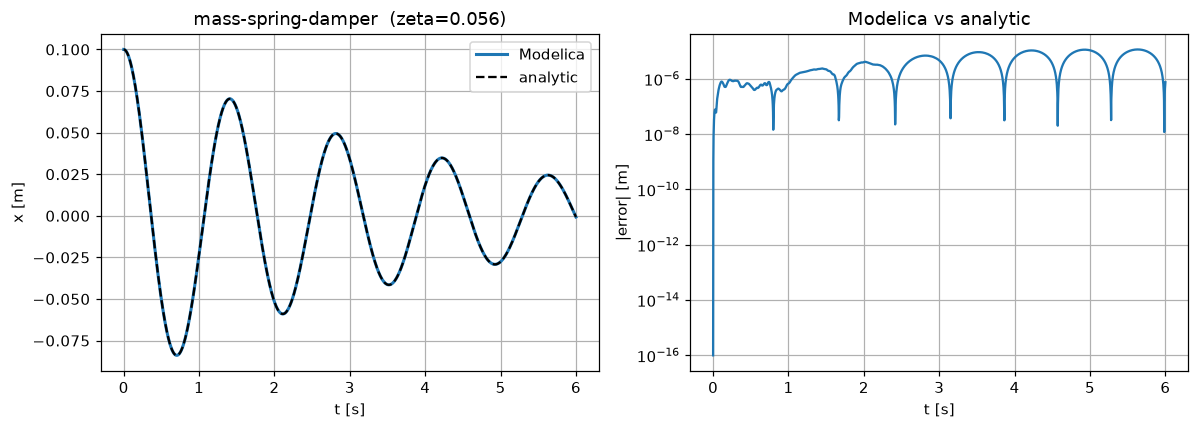

omega_n=4.472 rad/s  zeta=0.056  max abs error = 1.15e-05 m


In [2]:
m, c, k, x0 = 1.0, 0.5, 20.0, 0.10

msd_src = f"""
model MassSpringDamper
  parameter Real m = {m};
  parameter Real c = {c};
  parameter Real k = {k};
  Real x(start = {x0}, fixed = true);
  Real v(start = 0, fixed = true);
equation
  der(x) = v;
  m*der(v) + c*v + k*x = 0;
end MassSpringDamper;
"""

df, _ = run_modelica("MassSpringDamper", msd_src, stop=6.0)

wn = np.sqrt(k / m)
zeta = c / (2 * np.sqrt(k * m))
wd = wn * np.sqrt(1 - zeta**2)
t = df["time"].values
x_exact = x0 * np.exp(-zeta * wn * t) * (
    np.cos(wd * t) + zeta / np.sqrt(1 - zeta**2) * np.sin(wd * t))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, df["x"], lw=2, label="Modelica")
ax[0].plot(t, x_exact, "k--", label="analytic")
ax[0].set(xlabel="t [s]", ylabel="x [m]",
          title=f"mass-spring-damper  (zeta={zeta:.3f})")
ax[0].legend()
ax[1].semilogy(t, np.abs(df["x"].values - x_exact) + 1e-16)
ax[1].set(xlabel="t [s]", ylabel="|error| [m]", title="Modelica vs analytic")
fig.tight_layout()
plt.show()
print(f"omega_n={wn:.3f} rad/s  zeta={zeta:.3f}  max abs error = "
      f"{np.max(np.abs(df['x'].values - x_exact)):.2e} m")

## M1.2 RC network  -  step response

Series R, C driven by a voltage step $V_s$ from rest:

$$ RC\,\dot v_C + v_C = V_s
   \quad\Rightarrow\quad
   v_C(t) = V_s\left(1 - e^{-t/RC}\right) $$

Here I use the Modelica Standard Library electrical components and *wire* them,
which is the acausal style  -  no ODE written by hand.

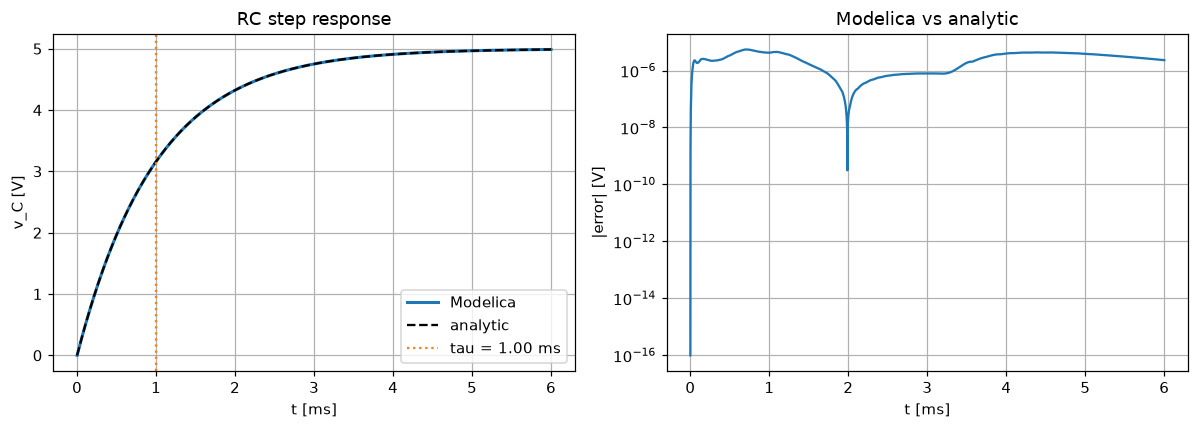

tau = 1.000 ms   max abs error = 5.49e-06 V


In [3]:
R, Cap, Vs = 1000.0, 1.0e-6, 5.0   # 1 kOhm, 1 uF -> tau = 1 ms

rc_src = """
model RCStep
  Modelica.Electrical.Analog.Basic.Resistor R(R = 1000);
  Modelica.Electrical.Analog.Basic.Capacitor C(C = 1e-6, v(start = 0, fixed = true));
  Modelica.Electrical.Analog.Sources.StepVoltage src(V = 5, startTime = 0);
  Modelica.Electrical.Analog.Basic.Ground gnd;
equation
  connect(src.p, R.p);
  connect(R.n, C.p);
  connect(C.n, src.n);
  connect(src.n, gnd.p);
end RCStep;
"""

df, log = run_modelica("RCStep", rc_src, stop=6e-3, interval=3000)
# MSL is needed -> load it in the .mos; patch loader:
if "C.v" not in df.columns:
    raise RuntimeError(log)

tau = R * Cap
t = df["time"].values
vc_exact = Vs * (1 - np.exp(-t / tau))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t * 1e3, df["C.v"], lw=2, label="Modelica")
ax[0].plot(t * 1e3, vc_exact, "k--", label="analytic")
ax[0].axvline(tau * 1e3, color="C1", ls=":", label=f"tau = {tau*1e3:.2f} ms")
ax[0].set(xlabel="t [ms]", ylabel="v_C [V]", title="RC step response")
ax[0].legend()
ax[1].semilogy(t * 1e3, np.abs(df["C.v"].values - vc_exact) + 1e-16)
ax[1].set(xlabel="t [ms]", ylabel="|error| [V]", title="Modelica vs analytic")
fig.tight_layout()
plt.show()
print(f"tau = {tau*1e3:.3f} ms   max abs error = "
      f"{np.max(np.abs(df['C.v'].values - vc_exact)):.2e} V")

## M1.3 Lumped thermal body cooling to ambient

A body of heat capacity $C_{th}$ at $T_0$, conductance $G$ to a fixed ambient
$T_\infty$, with a constant internal heat input $\dot Q$:

$$ C_{th}\dot T = \dot Q - G\,(T - T_\infty)
   \;\Rightarrow\;
   T(t) = T_\infty + \frac{\dot Q}{G}
          + \left(T_0 - T_\infty - \frac{\dot Q}{G}\right)e^{-t/\tau},
   \quad \tau = C_{th}/G $$

This is the exact same equation as A2 in the engineering notebook  -  here it is
assembled from MSL `HeatTransfer` components (`HeatCapacitor`,
`ThermalConductor`, `FixedTemperature`, `PrescribedHeatFlow`).

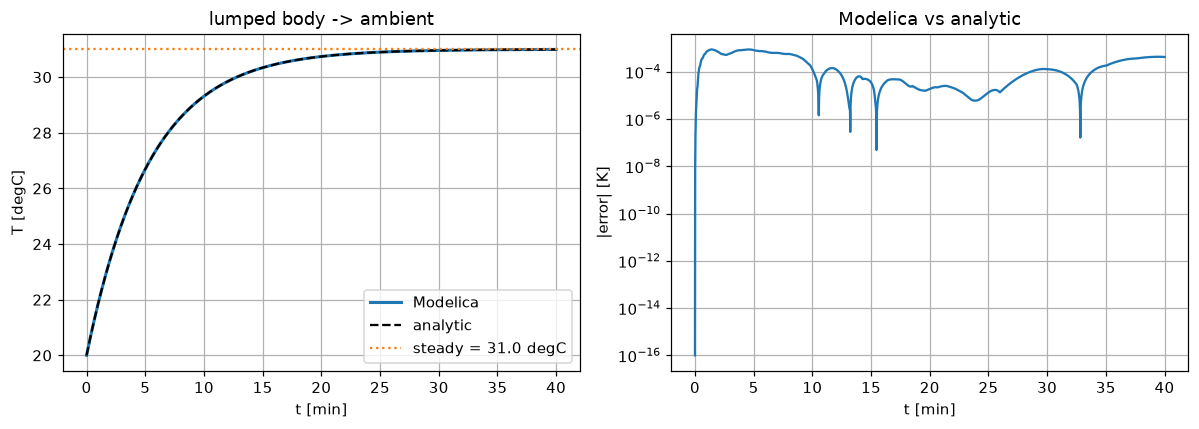

tau = 5.3 min   steady rise = 6.00 K   max abs error = 8.80e-04 K


In [4]:
Cth, G, T0, Tinf, Qdot = 800.0, 2.5, 20.0, 25.0, 15.0

th_src = """
model LumpedThermal
  Modelica.Thermal.HeatTransfer.Components.HeatCapacitor body(
    C = 800, T(start = 293.15, fixed = true));
  Modelica.Thermal.HeatTransfer.Components.ThermalConductor cond(G = 2.5);
  Modelica.Thermal.HeatTransfer.Sources.FixedTemperature amb(T = 298.15);
  Modelica.Thermal.HeatTransfer.Sources.PrescribedHeatFlow q;
  Modelica.Blocks.Sources.Constant qset(k = 15);
equation
  connect(q.port, body.port);
  connect(body.port, cond.port_a);
  connect(cond.port_b, amb.port);
  connect(qset.y, q.Q_flow);
end LumpedThermal;
"""

df, log = run_modelica("LumpedThermal", th_src, stop=2400.0, interval=3000)
col = "body.T" if "body.T" in df.columns else [c for c in df.columns if c.endswith("body.T")][0]

tau = Cth / G
t = df["time"].values
T_exact_C = Tinf + Qdot / G + (T0 - Tinf - Qdot / G) * np.exp(-t / tau)
T_model_C = df[col].values - 273.15

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t / 60, T_model_C, lw=2, label="Modelica")
ax[0].plot(t / 60, T_exact_C, "k--", label="analytic")
ax[0].axhline(Tinf + Qdot / G, color="C1", ls=":",
              label=f"steady = {Tinf + Qdot/G:.1f} degC")
ax[0].set(xlabel="t [min]", ylabel="T [degC]", title="lumped body -> ambient")
ax[0].legend()
ax[1].semilogy(t / 60, np.abs(T_model_C - T_exact_C) + 1e-16)
ax[1].set(xlabel="t [min]", ylabel="|error| [K]", title="Modelica vs analytic")
fig.tight_layout()
plt.show()
print(f"tau = {tau/60:.1f} min   steady rise = {Qdot/G:.2f} K   "
      f"max abs error = {np.max(np.abs(T_model_C - T_exact_C)):.2e} K")

## What M1 establishes

* The `omc` + `.mos` -> CSV -> matplotlib workflow is reproducible from a script,
  no GUI needed.
* All three models reproduce their closed-form solutions to solver tolerance.
* The acausal `connect(...)` style already appears in M1.2 / M1.3  -  the same
  pattern scales to the `BatteryTR` library (cells wired into modules wired into
  packs) without ever writing the assembled system equation by hand.

**Next (M2):** thermal-fluid components  -  a pipe / control volume with mass and
energy balance, a pump/fan characteristic, a simple heat exchanger, then a small
coolant loop. Then M3: a battery electrical-thermal plant (OCV-SOC + 1-RC +
self-heating), which is where this stream meets the Kaggle battery work.